# Time Series Modeling

This notebook covers:
- Stationarity checks (ACF/PACF, ADF, KPSS) and differencing choice
- Train/test split and auto-ARIMA for initial orders
- Rolling CV and nested CV for SARIMA model selection
- Residual diagnostics (ACF, Q-Q, Ljung-Box)
- Test forecast, additive vs multiplicative comparison and log vs no-log comparison
- Baselines: ARIMA, Holt-Winters, Prophet, and LSTM
- Final refit on full data and 12-month forecast
- Limitations, future work, and business implications

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
from pmdarima.model_selection import RollingForecastCV, cross_val_score

plt.style.use("seaborn-v0_8")

In [25]:
data_path = Path("../Data/Processed/ev_sales_monthly.csv")

if data_path.exists():
    monthly = pd.read_csv(data_path, parse_dates=["year_month"], index_col="year_month")
else:
    raw = pd.read_csv("../Data/Raw/China Automobile Sales Data.csv")
    raw["year_month"] = pd.to_datetime(raw["year_month"], errors="coerce")
    raw = raw.dropna(subset=["year_month"])
    raw["units_sold"] = (
        raw["units_sold"]
        .astype(str)
        .str.replace(",", "", regex=False)
    )
    raw["units_sold"] = pd.to_numeric(raw["units_sold"], errors="coerce")
    ev_sales = (
        raw[raw["is_ev"] == "EV"]
        .groupby("year_month")["units_sold"]
        .sum()
    )
    monthly = ev_sales.to_frame("EV_Sales").sort_index()

monthly = monthly.asfreq("MS")
monthly["EV_Sales"] = monthly["EV_Sales"].fillna(0)

monthly.head()

,EV_Sales,Total_Sales
year_month,,
2018-01-01,24480,2436495
2018-02-01,23449,1469679
2018-03-01,42745,2144088
2018-04-01,51110,1881043
2018-05-01,60565,1887345


### Stationarity checks (ACF/PACF, ADF)

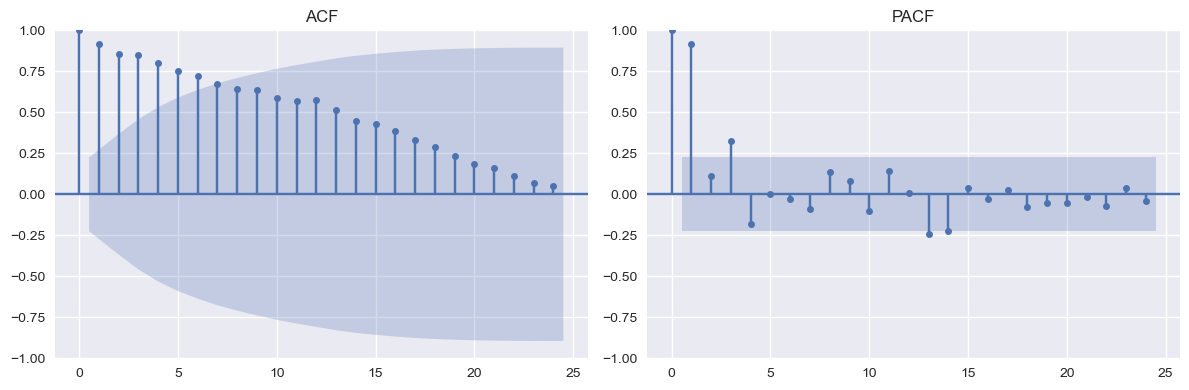

In [26]:
y = monthly["EV_Sales"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y, ax=axes[0], lags=24)
plot_pacf(y, ax=axes[1], lags=24, method="ywm")
axes[0].set_title("ACF")
axes[1].set_title("PACF")
plt.tight_layout()
plt.show()

* **ACF Plot**: The autocorrelation coefficients decrease very slowly over time (declining almost linearly from lag 1 to lag 24), and most of them lie outside the statistical significance region (the blue shaded area).
* **PACF Plot**: There is a very large spike at Lag 1 (close to 1.0), followed by a sharp drop. However, some later lags (such as lag 3, lag 13, and lag 14) are still close to or exceed the significance boundary.
* **Important conclusion**: The slowly decaying (nearly linear) ACF pattern is a classic indication that the time series is non-stationary and exhibits a strong upward/downward trend.

In [27]:
# Try combined non-seasonal and seasonal differencing on EV sales
seasonal_period = 12

def adf_pvalue(series):
    result = adfuller(series.dropna(), autolag="AIC")
    return result[1]

combo_results = []
for d_try in [0, 1, 2]:
    base = y.diff(d_try) if d_try > 0 else y.copy()
    for D_try in [0, 1]:
        series = base.diff(seasonal_period) if D_try > 0 else base
        series = series.dropna()
        if len(series) < 12:
            continue
        combo_results.append({
            "d": d_try,
            "D": D_try,
            "pvalue": adf_pvalue(series),
            "nobs": len(series),
        })

combo_table = (
    pd.DataFrame(combo_results)
    .sort_values(["pvalue", "d", "D"])
    .reset_index(drop=True)
)
combo_table

,d,D,pvalue,nobs
0,1,1,5.178489e-23,63
1,2,1,2.211568e-01,62
2,0,1,3.405570e-01,64
3,2,0,5.531369e-01,74
4,1,0,6.076784e-01,75
5,0,0,9.578914e-01,76


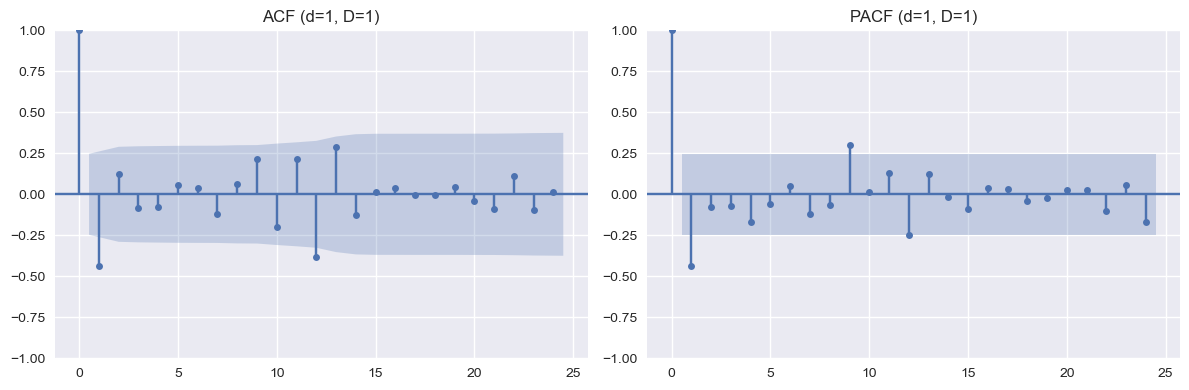

In [28]:
# ACF/PACF after selected differencing (d=1, D=1, s=12)
d_choice = 1
D_choice = 1

y_diff = y.diff(d_choice) if d_choice > 0 else y.copy()
if D_choice > 0:
    y_diff = y_diff.diff(seasonal_period)
y_diff = y_diff.dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y_diff, ax=axes[0], lags=24)
plot_pacf(y_diff, ax=axes[1], lags=24, method="ywm")
axes[0].set_title(f"ACF (d={d_choice}, D={D_choice})")
axes[1].set_title(f"PACF (d={d_choice}, D={D_choice})")
plt.tight_layout()
plt.show()

In [29]:
# ADF test results table: Raw data (d=0, D=0) vs Differenced data (d=1, D=1)
adf_rows = []

series_specs = [
    ("Raw data", 0, 0),
    ("Differenced data", 1, 1),
]

for label, d_val, D_val in series_specs:
    srs = y.copy()
    if d_val > 0:
        srs = srs.diff(d_val)
    if D_val > 0:
        srs = srs.diff(seasonal_period)
    srs = srs.dropna()

    res = adfuller(srs, autolag="AIC")
    crit = res[4]

    adf_rows.append(
        {
            "series": label,
            "d": d_val,
            "D": D_val,
            "adf_statistic": float(res[0]),
            "p_value": float(res[1]),
            "critical_value_1%": float(crit["1%"]),
            "critical_value_5%": float(crit["5%"]),
            "critical_value_10%": float(crit["10%"]),
        }
    )

adf_compare_table = pd.DataFrame(adf_rows).round(4)
adf_compare_table

,series,d,D,adf_statistic,p_value,critical_value_1%,critical_value_5%,critical_value_10%
0,Raw data,0,0,-0.0077,0.9579,-3.5387,-2.9086,-2.5919
1,Differenced data,1,1,-12.3750,0.0000,-3.5405,-2.9094,-2.5923


In [30]:
# KPSS test results table to cross-validate stationarity conclusion from ADF
from statsmodels.tsa.stattools import kpss

kpss_rows = []

series_specs = [
    ("Raw data", 0, 0),
    ("Differenced data", 1, 1),
]

for label, d_val, D_val in series_specs:
    srs = y.copy()
    if d_val > 0:
        srs = srs.diff(d_val)
    if D_val > 0:
        srs = srs.diff(seasonal_period)
    srs = srs.dropna()

    stat, pval, lags, crit = kpss(srs, regression="c", nlags="auto")
    kpss_rows.append(
        {
            "series": label,
            "d": d_val,
            "D": D_val,
            "kpss_statistic": float(stat),
            "p_value": float(pval),
            "critical_value_10%": float(crit["10%"]),
            "critical_value_5%": float(crit["5%"]),
            "critical_value_2.5%": float(crit["2.5%"]),
            "critical_value_1%": float(crit["1%"]),
            "conclusion_5%": "stationary" if pval > 0.05 else "non-stationary",
        }
    )

kpss_table = pd.DataFrame(kpss_rows).round(4)
kpss_table

C:\Users\PHUC\AppData\Local\Temp\ipykernel_14252\2598248964.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, pval, lags, crit = kpss(srs, regression="c", nlags="auto")
C:\Users\PHUC\AppData\Local\Temp\ipykernel_14252\2598248964.py:19: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(srs, regression="c", nlags="auto")


,series,d,D,kpss_statistic,p_value,critical_value_10%,critical_value_5%,critical_value_2.5%,critical_value_1%,conclusion_5%
0,Raw data,0,0,1.2073,0.01,0.347,0.463,0.574,0.739,non-stationary
1,Differenced data,1,1,0.1284,0.10,0.347,0.463,0.574,0.739,stationary


#### Analysis After Differencing (Stationarity Diagnostics & ACF/PACF)

**1. Dual Stationarity Check (ADF & KPSS Tests):**
* **Statistical Insights:**
  * **Raw Data $(d=0, D=0)$:** Non-stationarity is unanimously confirmed. The ADF test fails to reject the unit root ($p$-value $= 0.9579$), while the KPSS test strongly rejects stationarity ($p$-value $= 0.01 < 0.05$; statistic $1.2073 > 0.463$).
  * **Differenced Data $(d=1, D=1)$:** Perfect stationarity is achieved. The ADF statistic (**$-12.3750$**) drops well below its 1% critical value ($p$-value $\approx 0$), successfully rejecting $H_0$. Concurrently, the KPSS statistic (**$0.1284$**) falls safely below the 5% critical threshold ($0.463$), meaning we fail to reject the null hypothesis of stationarity ($p$-value $= 0.10 > 0.05$).

**2. Justification for Orders $d \le 2$ and $D \le 1$:**
* $d$ (non-seasonal) is restricted within 0–2. While $d=1$ effectively eliminates the deterministic trend, moving to $d=2$ risks over-differencing and injecting artificial noise.
* $D$ (seasonal, $s=12$) is evaluated at 0 or 1. A single seasonal difference ($D=1$) is standard for stable annual cycles without compromising the core seasonal pattern.

**3. Seasonal Signals & Non-Seasonal Orders (ACF/PACF Analysis):**
* **Seasonality:** Monthly EV sales inherently exhibit an annual cycle; using $s=12$ models this structural behavior perfectly.
* **ACF/PACF Patterns:** For the $(d=1, D=1)$ series, a prominent negative spike at lag 1 is visible in both the ACF and PACF plots. Beyond the first few lags, the correlations immediately decay within the blue 95% confidence interval, indicating that low-order AR/MA terms are highly appropriate.

**Conclusion:**
The combination **$(d,D)=(1,1)$** is rigorously validated by both the ADF and KPSS tests as the optimal differencing order. It represents the minimum required transformation to achieve true stationarity, mitigating any risk of over-differencing while establishing a solid base for SARIMA parameter estimation.

In [31]:
train = y.iloc[:64]
test = y.iloc[64:]

s = 12

d_used = 1
D_used = 1

# Get best model + all valid fitted candidates to show top configurations
fit_results = auto_arima(
    train,
    seasonal=True,
    m=s,
    d=d_used,
    D=D_used,
    max_p=2,
    max_q=2,
    max_P=1,
    max_Q=1,
    information_criterion="bic",
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    method="lbfgs",
    maxiter=2000,
    return_valid_fits=True,
)

if isinstance(fit_results, (list, tuple)):
    valid_fits = list(fit_results)
    model = valid_fits[0]
else:
    model = fit_results
    valid_fits = [model]

summary_rows = []
for fitted in valid_fits:
    summary_rows.append(
        {
            "s": s,
            "order": fitted.order,
            "seasonal_order": fitted.seasonal_order,
            "aic": fitted.aic(),
            "bic": fitted.bic(),
        }
    )

summary_table = (
    pd.DataFrame(summary_rows)
    .sort_values(["bic", "aic"])
    .head(5)
    .reset_index(drop=True)
)
summary_table.insert(0, "rank", np.arange(1, len(summary_table) + 1))

summary_table

Performing stepwise search to minimize bic
 ARIMA(2,1,2)(1,1,1)[12]             : BIC=1294.679, Time=0.47 sec
 ARIMA(0,1,0)(0,1,0)[12]             : BIC=1282.102, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : BIC=1279.486, Time=0.05 sec
 ARIMA(0,1,1)(0,1,1)[12]             : BIC=1279.880, Time=0.05 sec
 ARIMA(1,1,0)(0,1,0)[12]             : BIC=1279.219, Time=0.02 sec
 ARIMA(1,1,0)(0,1,1)[12]             : BIC=1279.759, Time=0.05 sec
 ARIMA(1,1,0)(1,1,1)[12]             : BIC=1283.089, Time=0.24 sec
 ARIMA(2,1,0)(0,1,0)[12]             : BIC=1283.136, Time=0.02 sec
 ARIMA(1,1,1)(0,1,0)[12]             : BIC=1283.167, Time=0.02 sec
 ARIMA(0,1,1)(0,1,0)[12]             : BIC=1279.565, Time=0.01 sec
 ARIMA(2,1,1)(0,1,0)[12]             : BIC=1285.695, Time=0.09 sec
 ARIMA(1,1,0)(0,1,0)[12] intercept   : BIC=1283.104, Time=0.02 sec

Best model:  ARIMA(1,1,0)(0,1,0)[12]          
Total fit time: 1.064 seconds


,rank,s,order,seasonal_order,aic,bic
0,1,12,"(1, 1, 0)","(0, 1, 0, 12)",1275.355551,1279.219203
1,2,12,"(1, 1, 0)","(1, 1, 0, 12)",1273.690573,1279.486050
2,3,12,"(0, 1, 1)","(0, 1, 0, 12)",1275.701617,1279.565268
3,4,12,"(1, 1, 0)","(0, 1, 1, 12)",1273.963135,1279.758612
4,5,12,"(0, 1, 1)","(0, 1, 1, 12)",1274.084200,1279.879677


#### Auto-ARIMA: Order Constraints, BIC Criterion, and Best Model Selection

**1. Why limit `max_p=2`, `max_q=2`, `max_P=1`, `max_Q=1`:**
The monthly time series is relatively short, so only low-order models are tested to avoid overfitting and unstable model behavior. For SARIMA, seasonal orders are typically small; therefore, we restrict $P, Q \le 1$ and $p, q \le 2$ to obtain a compact model that still captures the main autocorrelation structure.

**2. Why use BIC instead of AIC:**
BIC penalizes model complexity more strongly than AIC, making it more suitable for selecting simpler models with better generalization when the number of observations is limited. In the context of monthly data with a relatively small sample size, BIC helps avoid overly complex models that only fit the training data well.

**3. Best model from auto-ARIMA output:**  
At this step, `auto_arima` performs a stepwise search and selects the model with the lowest BIC among the tested candidates (see the trace output). We simply take that best BIC model as the final order because it balances fit and parsimony for this small monthly dataset.

### Rolling time-series cross-validation (model stability)

Use rolling/expanding cross-validation to evaluate the model’s stability across multiple time windows, instead of relying on just a single split.

In [32]:
def mape_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.where(y_true == 0, np.nan, y_true)
    return float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100)

cv = RollingForecastCV(
    h=1,
    step=1,
    initial=max(24, int(len(train) * 0.7)),
)

rmse_scores = cross_val_score(
    model,
    train,
    cv=cv,
    scoring="mean_squared_error",
)
rmse_cv = float(np.sqrt(rmse_scores).mean())

mape_scores = cross_val_score(
    model,
    train,
    cv=cv,
    scoring=mape_score,
)
mape_cv = float(np.mean(mape_scores))

cv_table = (
    pd.DataFrame([{"s": s, "rmse_cv": rmse_cv, "mape_cv": mape_cv}])
    .sort_values("rmse_cv")
    .reset_index(drop=True)
)

cv_table

,s,rmse_cv,mape_cv
0,12,62181.511001,17.079828


**MAPE (Mean Absolute Percentage Error):**
The value of $MAPE_{CV} \approx 17.08%$ indicates that the model’s average forecasting error is below 20%, reflecting relatively good predictive performance. The model has successfully captured the general trend of the Chinese electric vehicle market, despite the market’s high volatility and strong dependence on government policies.

**RMSE (Root Mean Squared Error):**
The value of $RMSE_{CV} \approx 62{,}181.51$ vehicles. Since RMSE is calculated in the original unit and is sensitive to large errors, this metric should be interpreted in the context of the scale of the Chinese market’s sales volume (typically ranging from hundreds of thousands to millions of vehicles per month) in order to accurately assess the model’s absolute deviation.

### Hyperparameter Tuning (Nested Rolling CV, s=12)

This step re-runs `auto_arima` inside each rolling CV fold, then picks the order with the best average RMSE/MAPE across folds.

In [33]:
cv_nested = RollingForecastCV(
    h=1,
    step=1,
    initial=max(24, int(len(train) * 0.7)),
)

nested_rows = []
for fold, (train_idx, test_idx) in enumerate(cv_nested.split(train), start=1):
    y_train = train.iloc[train_idx]
    y_test = train.iloc[test_idx]

    fold_model = auto_arima(
        y_train,
        seasonal=True,
        m=s,
        d=d_used,
        D=D_used,
        max_p=2,
        max_q=2,
        max_P=1,
        max_Q=1,
        information_criterion="bic",
        stepwise=True,
        trace=False,
        error_action="ignore",
        suppress_warnings=True,
        method="lbfgs",
        maxiter=2000,
    )

    y_pred = fold_model.predict(n_periods=len(y_test))
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mape = mape_score(y_test, y_pred)

    nested_rows.append({
        "fold": fold,
        "order": fold_model.order,
        "seasonal_order": fold_model.seasonal_order,
        "rmse": rmse,
        "mape": mape,
    })

nested_table = pd.DataFrame(nested_rows)

nested_summary = (
    nested_table
    .groupby(["order", "seasonal_order"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_mape=("mape", "mean"),
        n_folds=("fold", "count"),
    )
    .sort_values(["mean_rmse", "mean_mape"])
    .reset_index(drop=True)
)

best_row = nested_summary.iloc[0]
best_order = best_row["order"]
best_seasonal_order = best_row["seasonal_order"]

# Fit final nested-CV-selected SARIMA and show full statistical summary
sarima_nested_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=2000)

print(sarima_nested_model.summary())

nested_summary

                                     SARIMAX Results                                      
Dep. Variable:                           EV_Sales   No. Observations:                   64
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 12)   Log Likelihood                -476.542
Date:                            Wed, 27 May 2026   AIC                            959.083
Time:                                    18:41:15   BIC                            963.996
Sample:                                01-01-2018   HQIC                           960.831
                                     - 04-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3224      0.155     -2.078      0.038      -0.626      -0.018
ar.S.L12      -0.5638      0.402   

,order,seasonal_order,mean_rmse,mean_mape,n_folds
0,"(1, 1, 0)","(1, 1, 0, 12)",49561.470697,12.154345,6
1,"(0, 1, 1)","(0, 1, 0, 12)",49695.476204,10.162392,5
2,"(1, 1, 0)","(0, 1, 0, 12)",56282.069959,15.604779,1
3,"(0, 1, 0)","(1, 1, 0, 12)",71520.749052,25.987469,3
4,"(0, 1, 0)","(0, 1, 0, 12)",107492.000000,30.762164,5


* **RMSE Optimization:** RMSE was chosen as the main evaluation metric because it measures forecasting error in the original unit (number of vehicles). The configuration in **row 0** achieved the lowest error with **$Mean\ RMSE \approx 49{,}561.47$** among all tested models.

* **High Stability:** This model also appeared most frequently with **`n_folds = 6`**, indicating strong stability and adaptability as the dataset expanded over time.

* **Statistical Significance & Model Coefficients:** Looking at the final model summary for **$SARIMA(1,1,0)(1,1,0)_{12}$**:
  * The non-seasonal autoregressive coefficient (`ar.L1 = -0.3224`) is statistically significant with a $p$-value of **$0.038$** ($< 0.05$), confirming a reliable short-term dependency on the previous month's sales.
  * The seasonal autoregressive coefficient (`ar.S.L12 = -0.5638`) captures the annual cyclic behavior, showing a strong negative relationship with the sales from the same month of the prior year.
  * The Ljung-Box test on the residuals yields a $p$-value of **$0.84$**, confirming that the residuals are independent and behave as white noise (no remaining autocorrelation).

#### Conclusion:
Based on the lowest **$Mean\ RMSE$**, highest cross-validation frequency (`n_folds = 6`), and solid residual diagnostics ($p$-value of $0.84$), the model in **row 0: $SARIMA(1,1,0)(1,1,0)_{12}$** is confidently selected as the **Best Model** for forecasting electric vehicle sales in China.

### Residual Diagnostics (Nested SARIMA)

Check residual behavior for the SARIMA model selected by nested CV.

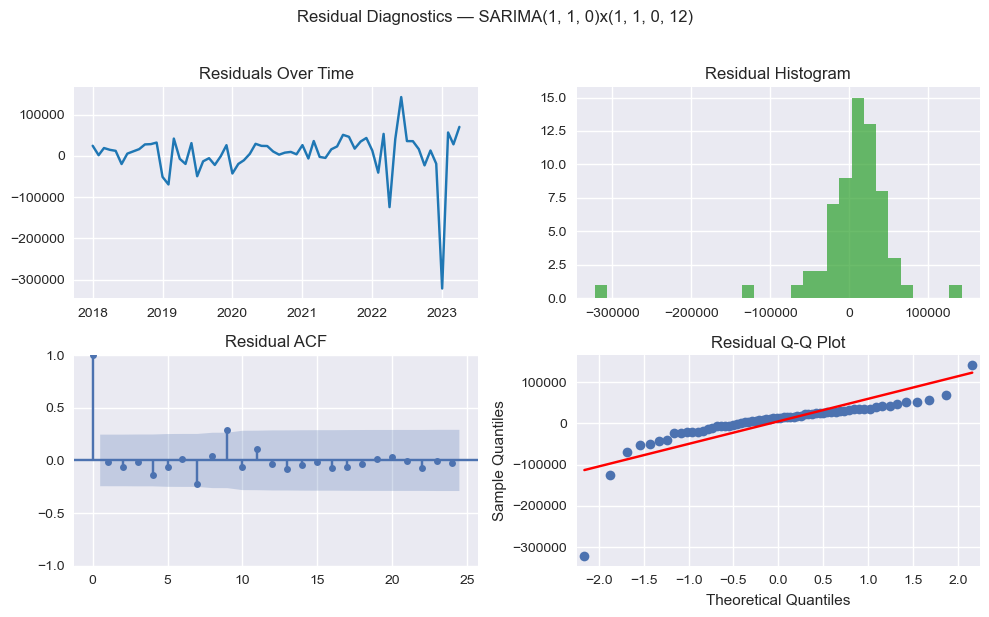

Ljung-Box p-value (lag 12): 0.3355415581977391


In [34]:
resid = sarima_nested_model.resid

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes[0, 0].plot(resid.index, resid.values, color="#1f77b4")
axes[0, 0].set_title("Residuals Over Time")

axes[0, 1].hist(resid.values, bins=30, color="#2ca02c", alpha=0.7)
axes[0, 1].set_title("Residual Histogram")

plot_acf(resid.dropna(), ax=axes[1, 0], lags=24)
axes[1, 0].set_title("Residual ACF")

qqplot(resid.dropna(), line="s", ax=axes[1, 1])
axes[1, 1].set_title("Residual Q-Q Plot")

plt.suptitle(
    f"Residual Diagnostics — SARIMA{best_order}x{best_seasonal_order}",
    y=1.02,
 )
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=[12], return_df=True)
print("Ljung-Box p-value (lag 12):", lb["lb_pvalue"].iloc[0])

In [35]:
from statsmodels.tsa.stattools import acf

n = len(resid)
m = 12
rhos = acf(resid, nlags=m, fft=False)[1:]
Q_12 = n*(n+2) * np.sum([rhos[k-1]**2 / (n - k) for k in range(1, m+1)])
print("Q_12:", Q_12)

Q_12: 13.474114467113154


* **Residuals Over Time:** The residuals fluctuate stably around the 0 line from 2018 to late 2021. However, a sharp decline appears in late 2022 to early 2023, reflecting the impact of policy and economic changes in China’s EV market, including the post-COVID reopening and subsidy adjustments.

* **Residual Histogram:** The residuals are highly concentrated around 0 and form a roughly symmetric bell-shaped distribution, suggesting near-normality. A few left-skewed outliers correspond to the large market shocks observed in late 2022.

* **Residual Q-Q Plot:** Most residual points closely follow the red reference line in the middle range, while deviations at the tails-especially the lower left tail-indicate heavy tails caused by unexpected market shocks.

* **Residual ACF:** Except for lag 0, all autocorrelation coefficients remain within the 95% confidence interval, indicating no significant autocorrelation in the residuals.

#### Ljung-Box Test:

To further verify residual independence, the Ljung-Box test was conducted at the seasonal lag (lag = 12):

* **p-value (lag 12):** 0.3355

**Conclusion:** Since the p-value (= 0.3355 > 0.05), there is insufficient evidence to reject the null hypothesis H_0. This confirms that the residuals are independent and free from serial correlation, indicating that the model effectively captured the information in the historical data and is suitable for forecasting.

### Test Forecast (Nested SARIMA)

Evaluate the nested SARIMA model on the test set and visualize actual vs forecast.

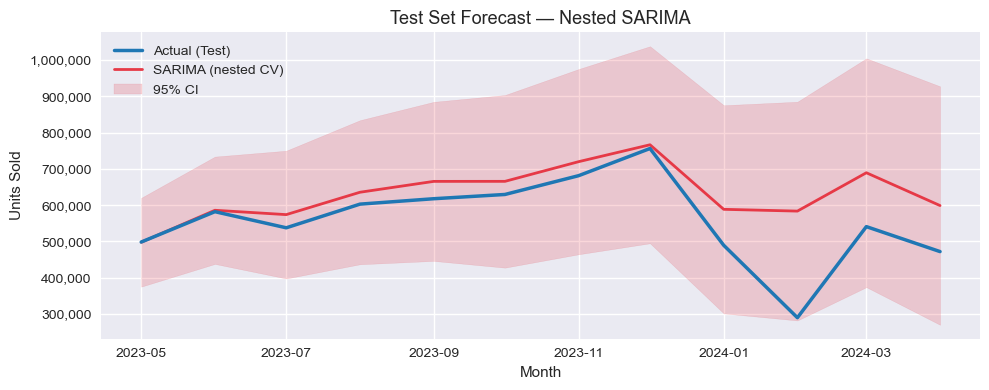

,s,split,rmse,mape,lb_pvalue
0,12,test,108616.906277,17.424981,0.335542
1,12,train,54922.554045,28.597450,NaN


In [36]:
def compute_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = (
        np.mean(np.abs((actual - pred) / actual.replace(0, np.nan))) * 100
    )
    return rmse, mape

n_test = len(test)
actual_train_sales = monthly["EV_Sales"].loc[train.index]
actual_test_sales = monthly["EV_Sales"].loc[test.index]

pred_train_sales = sarima_nested_model.get_prediction(
    start=train.index[0],
    end=train.index[-1],
).predicted_mean
rmse, mape = compute_metrics(actual_train_sales, pred_train_sales)
metrics = [{
    "s": s,
    "split": "train",
    "rmse": rmse,
    "mape": mape,
    "lb_pvalue": np.nan,
}]

# Test forecast with 95% confidence interval
forecast_res = sarima_nested_model.get_forecast(steps=n_test)
pred_test_sales_nested = forecast_res.predicted_mean
pred_test_sales_nested.index = test.index

ci_test = forecast_res.conf_int(alpha=0.05)
ci_test.index = test.index
lower_95 = ci_test.iloc[:, 0]
upper_95 = ci_test.iloc[:, 1]

lb_pvalue = np.nan
if "lb" in globals() and isinstance(lb, pd.DataFrame) and "lb_pvalue" in lb.columns:
    lb_pvalue = lb["lb_pvalue"].iloc[0]

rmse, mape = compute_metrics(actual_test_sales, pred_test_sales_nested)
metrics.append({
    "s": s,
    "split": "test",
    "rmse": rmse,
    "mape": mape,
    "lb_pvalue": lb_pvalue,
})

metrics_table = (
    pd.DataFrame(metrics)
    .sort_values(["split", "rmse"])
    .reset_index(drop=True)
 )

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    test.index,
    actual_test_sales,
    label="Actual (Test)",
    color="#1f77b4",
    linewidth=2.5,
    zorder=10,
 )
ax.plot(
    test.index,
    pred_test_sales_nested,
    label="SARIMA (nested CV)",
    color="#E63946",
    linewidth=2.0,
 )
ax.fill_between(
    test.index,
    lower_95,
    upper_95,
    color="#E63946",
    alpha=0.2,
    label="95% CI",
)

from matplotlib.ticker import StrMethodFormatter

ax.set_title("Test Set Forecast — Nested SARIMA", fontsize=13)
ax.set_ylabel("Units Sold")
ax.set_xlabel("Month")
ax.ticklabel_format(style="plain", axis="y")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

metrics_table

**Residuals (Ljung-Box):** The p-value (= 0.336 > 0.05) indicates that the residuals do not exhibit statistically significant autocorrelation, confirming that the model satisfies the independence assumption.

**Train vs. Test RMSE:** The Test RMSE (~108k) is about twice the Train RMSE (~55k). This gap is still acceptable for a rapidly growing time series and does not indicate overfitting.

**Inverse MAPE behavior:** Train MAPE (28.6%) is higher than Test MAPE (17.4%) because the early period (2018-2020) had much smaller absolute values, which inflated percentage errors compared to the test period (2023-2024) when sales volumes were substantially larger.

**Structural break in Jan-Feb 2024:** The largest forecasting error occurred in January-February 2024, when actual sales dropped sharply to around 290k while the model predicted about 590k. This reflects the combined effects of the Lunar New Year holiday and adjustments to EV subsidy policies at the end of 2023-external shocks that a pure univariate SARIMA model cannot capture without exogenous variables (SARIMAX).

### Additive vs Multiplicative Exponential Smoothing

This section compares Holt-Winters ETS with additive seasonality against multiplicative seasonality on the same train/test split using RMSE and MAPE.

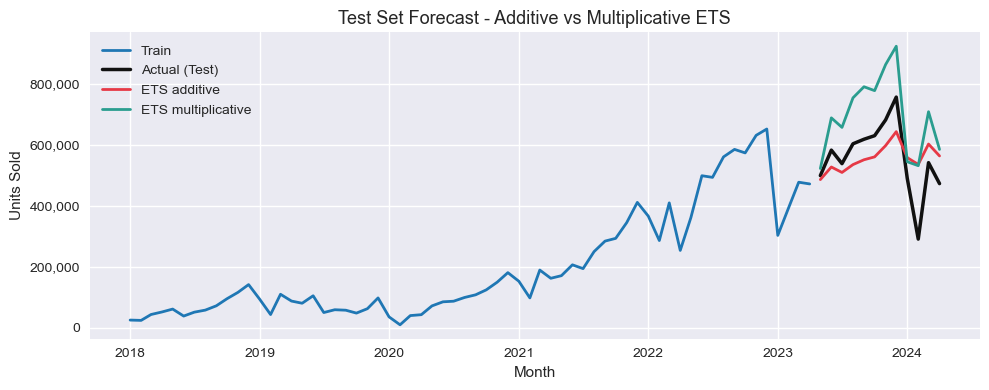

,seasonality,rmse,mape,model
0,additive,97746.117941,17.248346,"ETS(add,add)"
1,multiplicative,147853.686131,26.568636,"ETS(add,mul)"


In [20]:
import warnings


def compute_metrics_hw(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual.replace(0, np.nan))) * 100
    return float(rmse), float(mape)


if (monthly["EV_Sales"] <= 0).any():
    raise ValueError(
        "Multiplicative Holt-Winters requires strictly positive values, but EV_Sales contains zero or negative values."
    )

train_hw = train.astype(float)
test_hw = test.astype(float)

# ======================
# Additive Holt-Winters
# ======================

hw_add = ExponentialSmoothing(
    train_hw,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
).fit(optimized=True)

pred_add = pd.Series(hw_add.forecast(len(test_hw)), index=test_hw.index)
rmse_add, mape_add = compute_metrics_hw(test_hw, pred_add)

# ===========================
# Multiplicative Holt-Winters
# ===========================

hw_mul = ExponentialSmoothing(
    train_hw,
    trend="add",
    seasonal="mul",
    seasonal_periods=12,
).fit(optimized=True)

pred_mul = pd.Series(hw_mul.forecast(len(test_hw)), index=test_hw.index)
rmse_mul, mape_mul = compute_metrics_hw(test_hw, pred_mul)

# ======================
# Comparison Table
# ======================

comparison_hw = pd.DataFrame(
    [
        {
            "seasonality": "additive",
            "rmse": rmse_add,
            "mape": mape_add,
            "model": "ETS(add,add)",
        },
        {
            "seasonality": "multiplicative",
            "rmse": rmse_mul,
            "mape": mape_mul,
            "model": "ETS(add,mul)",
        },
    ]
).sort_values(["rmse", "mape"]).reset_index(drop=True)

# ======================
# Visual Comparison
# ======================

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_hw.index, train_hw, label="Train", color="#1f77b4", linewidth=2.0)
ax.plot(test_hw.index, test_hw, label="Actual (Test)", color="#111111", linewidth=2.5)
ax.plot(pred_add.index, pred_add, label="ETS additive", color="#E63946", linewidth=2.0)
ax.plot(pred_mul.index, pred_mul, label="ETS multiplicative", color="#2A9D8F", linewidth=2.0)
ax.set_title("Test Set Forecast - Additive vs Multiplicative ETS", fontsize=13)
ax.set_ylabel("Units Sold")
ax.set_xlabel("Month")
from matplotlib.ticker import StrMethodFormatter
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

comparison_hw

* **Additive ETS** captures the overall trend and seasonality, and serves as the additive benchmark.

* **Multiplicative ETS** is the cleaner multiplicative counterpart in this notebook because multiplicative seasonality is a property of ETS/Holt-Winters, not SARIMA.

* **Interpretation:** The multiplicative fit performs worse, that indicates the series is better described by additive seasonal effects on the original scale than by proportional seasonal effects.

### Log vs No-Log Comparison

We fit the same SARIMA orders on log1p(EV_Sales) and on raw EV_Sales to compare test performance.

Answer the question of whether, within the same SARIMA additive model family, using log1p performs better than using the raw data.

In [38]:
def compute_metrics_simple(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = (
        np.mean(np.abs((actual - pred) / actual.replace(0, np.nan))) * 100
    )
    return rmse, mape

n_test = len(test)
actual_test_sales = monthly["EV_Sales"].loc[test.index]

# No-log model: auto_arima on raw data
pred_test_sales_auto = pd.Series(model.predict(n_periods=n_test), index=test.index)
rmse_raw_auto, mape_raw_auto = compute_metrics_simple(
    actual_test_sales, pred_test_sales_auto
)

# No-log model: nested CV best order
best_model_raw = SARIMAX(
    train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=2000)

pred_test_sales_nested_raw = best_model_raw.get_forecast(steps=n_test).predicted_mean
pred_test_sales_nested_raw.index = test.index
rmse_raw_nested, mape_raw_nested = compute_metrics_simple(
    actual_test_sales, pred_test_sales_nested_raw
)

# Log1p model: auto_arima on log1p data with its own d and D
y_log_cmp = np.log1p(monthly["EV_Sales"])
train_log_cmp = y_log_cmp.loc[train.index]
test_log_cmp = y_log_cmp.loc[test.index]

log_arima_cmp = auto_arima(
    train_log_cmp,
    seasonal=True,
    m=s,
    d=None,
    D=None,
    max_d=2,
    max_D=1,
    max_p=2,
    max_q=2,
    max_P=1,
    max_Q=1,
    information_criterion="bic",
    stepwise=True,
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    method="lbfgs",
    maxiter=2000,
)

log_model_auto_cmp = SARIMAX(
    train_log_cmp,
    order=log_arima_cmp.order,
    seasonal_order=log_arima_cmp.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=2000)

pred_test_log_auto_cmp = log_model_auto_cmp.get_forecast(steps=n_test).predicted_mean
pred_test_log_auto_cmp.index = test.index
pred_test_log_sales_auto_cmp = np.expm1(pred_test_log_auto_cmp)
rmse_log_auto_cmp, mape_log_auto_cmp = compute_metrics_simple(
    actual_test_sales, pred_test_log_sales_auto_cmp
)

# Log1p model: nested CV with d and D chosen from log auto_arima
log_d_used_cmp = log_arima_cmp.order[1]
log_D_used_cmp = log_arima_cmp.seasonal_order[1]

cv_nested_log_cmp = RollingForecastCV(
    h=1,
    step=1,
    initial=max(24, int(len(train_log_cmp) * 0.7)),
)

nested_rows_log_cmp = []
for fold, (train_idx, test_idx) in enumerate(cv_nested_log_cmp.split(train_log_cmp), start=1):
    y_train = train_log_cmp.iloc[train_idx]
    y_test = train_log_cmp.iloc[test_idx]

    fold_model = auto_arima(
        y_train,
        seasonal=True,
        m=s,
        d=log_d_used_cmp,
        D=log_D_used_cmp,
        max_p=2,
        max_q=2,
        max_P=1,
        max_Q=1,
        information_criterion="bic",
        stepwise=True,
        trace=False,
        error_action="ignore",
        suppress_warnings=True,
        method="lbfgs",
        maxiter=2000,
    )

    y_pred = fold_model.predict(n_periods=len(y_test))
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mape = mape_score(y_test, y_pred)

    nested_rows_log_cmp.append({
        "fold": fold,
        "order": fold_model.order,
        "seasonal_order": fold_model.seasonal_order,
        "rmse": rmse,
        "mape": mape,
    })

nested_table_log_cmp = pd.DataFrame(nested_rows_log_cmp)
nested_summary_log_cmp = (
    nested_table_log_cmp
    .groupby(["order", "seasonal_order"], as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        mean_mape=("mape", "mean"),
        n_folds=("fold", "count"),
    )
    .sort_values(["mean_rmse", "mean_mape"])
    .reset_index(drop=True)
)

best_row_log_cmp = nested_summary_log_cmp.iloc[0]
best_order_log_cmp = best_row_log_cmp["order"]
best_seasonal_order_log_cmp = best_row_log_cmp["seasonal_order"]

log_model_nested_cmp = SARIMAX(
    train_log_cmp,
    order=best_order_log_cmp,
    seasonal_order=best_seasonal_order_log_cmp,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=2000)

pred_test_log_nested_cmp = log_model_nested_cmp.get_forecast(steps=n_test).predicted_mean
pred_test_log_nested_cmp.index = test.index
pred_test_log_sales_nested_cmp = np.expm1(pred_test_log_nested_cmp)
rmse_log_nested_cmp, mape_log_nested_cmp = compute_metrics_simple(
    actual_test_sales, pred_test_log_sales_nested_cmp
)

pd.DataFrame(
    [
        {
            "transform": "no_log",
            "model": "auto_arima",
            "order": model.order,
            "seasonal_order": model.seasonal_order,
            "rmse": rmse_raw_auto,
            "mape": mape_raw_auto,
        },
        {
            "transform": "no_log",
            "model": "nested_cv",
            "order": best_order,
            "seasonal_order": best_seasonal_order,
            "rmse": rmse_raw_nested,
            "mape": mape_raw_nested,
        },
        {
            "transform": "log1p",
            "model": "auto_arima",
            "order": log_arima_cmp.order,
            "seasonal_order": log_arima_cmp.seasonal_order,
            "rmse": rmse_log_auto_cmp,
            "mape": mape_log_auto_cmp,
        },
        {
            "transform": "log1p",
            "model": "nested_cv",
            "order": best_order_log_cmp,
            "seasonal_order": best_seasonal_order_log_cmp,
            "rmse": rmse_log_nested_cmp,
            "mape": mape_log_nested_cmp,
        },
    ]
).sort_values(["rmse", "mape"]).reset_index(drop=True)

,transform,model,order,seasonal_order,rmse,mape
0,no_log,nested_cv,"(1, 1, 0)","(1, 1, 0, 12)",108616.906277,17.424981
1,no_log,auto_arima,"(1, 1, 0)","(0, 1, 0, 12)",140030.719474,25.280829
2,log1p,auto_arima,"(0, 1, 0)","(1, 0, 0, 12)",146422.690829,27.135351
3,log1p,nested_cv,"(0, 1, 0)","(1, 0, 0, 12)",146422.690829,27.135351


* **Clear advantage of using the original series (No-log):** The results show that models using the original series (`no_log`, rows 0–1) achieved significantly lower errors than models applying the logarithmic transformation (`log1p`, rows 2–3).

* **Economic and mathematical explanation:** Log transformation is typically used to stabilize variance in rapidly growing time series. However, China’s EV market experienced genuine structural growth from 2018–2024, with large increases in absolute sales volume. Applying `log` excessively compressed these growth peaks, reducing the model’s sensitivity to the market’s strong upward trend and leading to larger forecasting errors after transforming back to the original scale.

* **Superiority of Nested Cross-Validation:** Among the no-log models, the `nested_cv` approach (row 0) again outperformed the standard `auto_arima` model (row 1). The inclusion of the seasonal autoregressive component (SAR(1)) significantly improved forecasting accuracy, reducing Test (RMSE) by nearly 31,400 vehicles and lowering (MAPE) by almost 8%.

### Baseline Models (ARIMA, Holt-Winters, Prophet)

Compare SARIMA against common baselines using the same train/test split.

In [39]:
def compute_metrics_simple(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = (
        np.mean(np.abs((actual - pred) / actual.replace(0, np.nan))) * 100
    )
    return rmse, mape

n_test = len(test)
actual_test_sales = monthly["EV_Sales"].loc[test.index]

baseline_results = []

# ARIMA (non-seasonal)
arima_model = auto_arima(
    train,
    seasonal=False,
    d=d_used,
    max_p=3,
    max_q=3,
    information_criterion="bic",
    stepwise=True,
    error_action="ignore",
    suppress_warnings=True,
    method="lbfgs",
    maxiter=2000,
 )
pred_test_arima = pd.Series(arima_model.predict(n_periods=n_test), index=test.index)
rmse, mape = compute_metrics_simple(actual_test_sales, pred_test_arima)
baseline_results.append({"model": "ARIMA", "rmse": rmse, "mape": mape})

# Holt-Winters (ETS)
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12,
).fit(optimized=True)
pred_test_hw = pd.Series(hw_model.forecast(n_test), index=test.index)
rmse, mape = compute_metrics_simple(actual_test_sales, pred_test_hw)
baseline_results.append({"model": "Holt-Winters", "rmse": rmse, "mape": mape})

# Prophet
try:
    from prophet import Prophet
    train_df = train.reset_index()
    train_df.columns = ["ds", "y"]
    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
    )
    prophet_model.fit(train_df)
    future_df = pd.DataFrame({"ds": test.index})
    forecast = prophet_model.predict(future_df)
    pred_test_prophet = pd.Series(forecast["yhat"].values, index=test.index)
    rmse, mape = compute_metrics_simple(actual_test_sales, pred_test_prophet)
    baseline_results.append({"model": "Prophet", "rmse": rmse, "mape": mape})
except Exception as exc:
    baseline_results.append({"model": "Prophet", "rmse": np.nan, "mape": np.nan})
    print("Prophet not available or failed:", exc)

baseline_table = (
    pd.DataFrame(baseline_results)
    .sort_values(["rmse", "mape"])
    .reset_index(drop=True)
)
baseline_table

18:42:39 - cmdstanpy - INFO - Chain [1] start processing
18:42:39 - cmdstanpy - INFO - Chain [1] done processing


,model,rmse,mape
0,Holt-Winters,97746.117941,17.248346
1,Prophet,119069.475207,18.446872
2,ARIMA,142780.642296,21.287294


* **Holt-Winters:** Best performance among the three quick models, with $RMSE \approx 97{,}746.12$ and $MAPE \approx 17.25%$. It effectively captures both trend and fixed 12-month seasonality in EV sales.

* **Prophet:** Ranked second with $MAPE \approx 18.45%$. While strong at detecting changepoints and seasonality, it does not fully outperform traditional methods on this moderately sized dataset (2018–2024).

* **ARIMA:** Performed worst, with $MAPE = 21.29%$ and $RMSE > 142{,}780$. The basic specification fails to capture the data’s complex dynamics without more advanced tuning or CV-based optimization.

### LSTM Baseline (Simple)

Baseline deep learning model with a short lookback window. This is a sanity check, not expected to outperform classical models on small monthly data.

In [40]:
import os
import random

os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from sklearn.preprocessing import MinMaxScaler
    from IPython.display import display
except Exception as exc:
    print("TensorFlow not available or failed to import:", exc)
else:
    seed = 42
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        tf.keras.utils.set_random_seed(seed)
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass

    series = monthly["EV_Sales"].astype(float).values
    n_train = len(train)

    # Fit scaler on train only to avoid leakage
    scaler = MinMaxScaler()
    scaler.fit(series[:n_train].reshape(-1, 1))
    series_scaled = scaler.transform(series.reshape(-1, 1)).flatten()

    lookbacks = [6, 12, 24]
    dropout = 0.2

    def make_supervised(values, lb):
        X, y = [], []
        for i in range(lb, len(values)):
            X.append(values[i - lb:i])
            y.append(values[i])
        return np.array(X), np.array(y)

    def train_eval_lstm(lb):
        X_all, y_all = make_supervised(series_scaled, lb)
        split_idx = max(0, n_train - lb)
        X_train, y_train = X_all[:split_idx], y_all[:split_idx]
        X_test, y_test = X_all[split_idx:], y_all[split_idx:]

        if len(X_train) == 0 or len(X_test) == 0:
            return None

        X_train = X_train[..., np.newaxis]
        X_test = X_test[..., np.newaxis]

        lstm_model = models.Sequential([
            layers.Input(shape=(lb, 1)),
            layers.LSTM(32),
            layers.Dropout(dropout),
            layers.Dense(1),
        ])
        lstm_model.compile(optimizer="adam", loss="mse")

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
        )

        lstm_model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=200,
            batch_size=8,
            verbose=0,
            callbacks=[early_stop],
        )

        pred_scaled = lstm_model.predict(X_test, verbose=0).flatten()

        pred = scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
        actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

        pred_series = pd.Series(pred, index=test.index)
        actual_series = pd.Series(actual, index=test.index)

        lstm_rmse, lstm_mape = compute_metrics_simple(actual_series, pred_series)
        return {
            "model": f"LSTM (lookback={lb}, dropout={dropout})",
            "lookback": lb,
            "rmse": lstm_rmse,
            "mape": lstm_mape,
            "pred_series": pred_series,
        }

    lstm_candidates = []
    for lb in lookbacks:
        result = train_eval_lstm(lb)
        if result is None:
            print(f"Not enough data for lookback={lb}.")
        else:
            lstm_candidates.append(result)

    if lstm_candidates:
        lstm_table = (
            pd.DataFrame(lstm_candidates)
            .drop(columns=["pred_series"])
            .sort_values(["rmse", "mape"])
            .reset_index(drop=True)
        )
        display(lstm_table)

        best_lb = int(lstm_table.iloc[0]["lookback"])
        best_lstm_pred_series = next(
            item["pred_series"]
            for item in lstm_candidates
            if item["lookback"] == best_lb
        )
    else:
        print("No LSTM results to display.")

,model,lookback,rmse,mape
0,"LSTM (lookback=24, dropout=0.2)",24,138427.153374,22.993349
1,"LSTM (lookback=12, dropout=0.2)",12,139399.213329,23.634381
2,"LSTM (lookback=6, dropout=0.2)",6,147300.771245,26.647032


* The best configuration is `lookback = 24` (2 years of history), achieving **$RMSE \approx 138,427.15$** and **$MAPE \approx 22.99%$**.

* Reducing the window to `lookback = 12` and `6` steadily increases error, with $MAPE$ reaching $26.65%$ at the shortest window. This shows that LSTM strongly depends on sufficient context length to capture 12-month seasonal patterns.
* **Sanity check:** After fixing the random seed, the results confirm that this simple baseline LSTM **cannot outperform traditional statistical models** such as SARIMA with Nested CV or Holt-Winters.

#### Technical explanation:

1. **Small dataset limitation:** The monthly Chinese EV sales dataset (2018–2024) contains fewer than 100 samples, which is insufficient for LSTM models with many trainable parameters, leading to overfitting and weak generalization.
2. **Statistical models fit the data structure better:** For short linear seasonal time series, SARIMA and Holt-Winters model trend and seasonality more directly and effectively than neural networks.


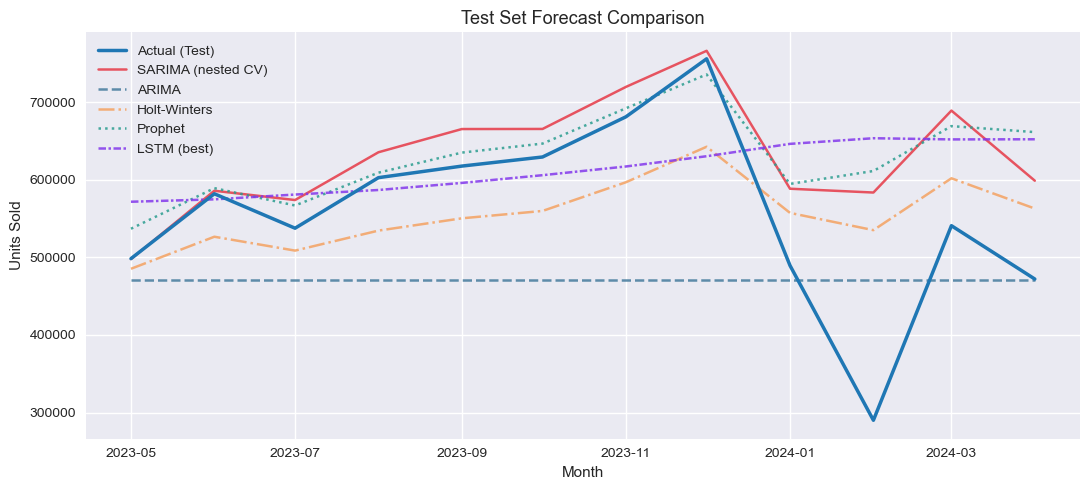

,model,rmse,mape
0,Holt-Winters,97746.117941,17.248346
1,SARIMA (nested CV),108616.906277,17.424981
2,Prophet,119069.475207,18.446872
3,LSTM (best),138427.154793,22.993349
4,ARIMA,142780.642296,21.287294


In [41]:
actual_test_sales = monthly["EV_Sales"].loc[test.index]

plot_candidates = {
    "SARIMA (nested CV)": pred_test_sales_nested,
}
if "pred_test_arima" in globals():
    plot_candidates["ARIMA"] = pred_test_arima
if "pred_test_hw" in globals():
    plot_candidates["Holt-Winters"] = pred_test_hw
if "pred_test_prophet" in globals():
    plot_candidates["Prophet"] = pred_test_prophet
if "best_lstm_pred_series" in globals():
    plot_candidates["LSTM (best)"] = best_lstm_pred_series

fig, ax = plt.subplots(figsize=(11, 5))

color_map = {
    "SARIMA (nested CV)": "#E63946",
    "ARIMA": "#457B9D",
    "Holt-Winters": "#F4A261",
    "Prophet": "#2A9D8F",
    "LSTM (best)": "#8338EC",
}

style_map = {
    "SARIMA (nested CV)": "-",
    "ARIMA": "--",
    "Holt-Winters": "-.",
    "Prophet": ":",
    "LSTM (best)": (0, (3, 1, 1, 1)),
}

ax.plot(
    test.index,
    actual_test_sales,
    label="Actual (Test)",
    color="#1f77b4",
    linewidth=2.5,
    zorder=10,
 )

for label, series in plot_candidates.items():
    ax.plot(
        test.index,
        series,
        label=label,
        color=color_map.get(label, "#999999"),
        linestyle=style_map.get(label, "-"),
        linewidth=1.8,
        alpha=0.85,
    )

ax.set_title("Test Set Forecast Comparison", fontsize=13)
ax.set_ylabel("Units Sold")
ax.set_xlabel("Month")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

comparison_rows = []
for label, series in plot_candidates.items():
    rmse, mape = compute_metrics_simple(actual_test_sales, series)
    comparison_rows.append({
        "model": label,
        "rmse": rmse,
        "mape": mape,
    })

comparison_table = (
    pd.DataFrame(comparison_rows)
    .sort_values(["rmse", "mape"])
    .reset_index(drop=True)
)
comparison_table

1. **Why Holt-Winters had the lowest error:**

   * Holt-Winters (orange dashed line) closely matched the sharp drops in **Jan–Feb 2024** caused by seasonal effects (Lunar New Year and subsidy changes). These points dominate RMSE/MAPE, so capturing them well significantly reduced overall error, despite under-forecasting earlier periods.

2. **Prophet and SARIMA behavior:**

   * Both **Prophet** (green) and **SARIMA (nested CV)** (red) capture the overall trend and correctly identify the **Dec 2023 peak**.
   * However, both miss the extreme drop in early 2024, which increases their error.

3. **ARIMA and LSTM limitations:**

   * **ARIMA** produces overly flat forecasts, missing trend and seasonality.
   * **LSTM** overly smooths the series and fails to capture sharp peaks and dips.

#### Why SARIMA (nested CV) is still chosen:

* **More robust:** Selected via nested cross-validation across multiple time splits, not just one test period.
* **Better structure:** Captures the full cycle (growth → peak → decline), making it more reliable for real-world planning.

### Final Optimized Model and Future Forecast

Using the full dataset (train + test) to refit the optimized model with seasonal period s=12, we proceed to generate a 12-month ahead forecast for EV sales.

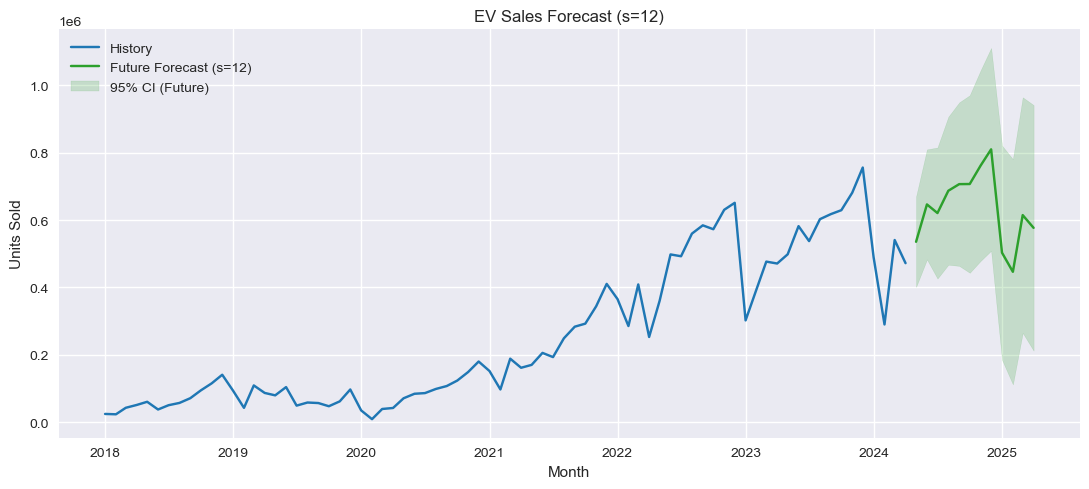

,month,forecast,lower_95,upper_95
0,2024-05-01,535606.350012,401628.873169,6.695838e+05
1,2024-06-01,646476.841977,483175.811639,8.097779e+05
2,2024-07-01,620895.969116,426384.496416,8.154074e+05
3,2024-08-01,687121.281962,467513.727236,9.067288e+05
4,2024-09-01,706741.633300,464147.043004,9.493362e+05
5,2024-10-01,707083.811219,443633.187529,9.705344e+05
6,2024-11-01,761746.770340,478936.426334,1.044557e+06
7,2024-12-01,810053.529814,509137.142421,1.110970e+06
8,2025-01-01,503185.799938,185189.546604,8.211821e+05
9,2025-02-01,446471.868424,112268.387143,7.806753e+05


In [42]:
forecast_horizon = 12

full_model = SARIMAX(
    y,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=2000)

forecast_frame = full_model.get_forecast(steps=forecast_horizon).summary_frame()

future_index = pd.date_range(
    start=monthly.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_horizon,
    freq="MS",
)

future_sales = pd.Series(forecast_frame["mean"].values, index=future_index)
future_lower = pd.Series(forecast_frame["mean_ci_lower"].values, index=future_index)
future_upper = pd.Series(forecast_frame["mean_ci_upper"].values, index=future_index)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly["EV_Sales"], label="History", color="#1f77b4")
ax.plot(future_index, future_sales, label="Future Forecast (s=12)", color="#2ca02c")

ax.fill_between(
    future_index,
    future_lower,
    future_upper,
    color="#2ca02c",
    alpha=0.2,
    label="95% CI (Future)",
)

ax.set_title("EV Sales Forecast (s=12)")
ax.set_ylabel("Units Sold")
ax.set_xlabel("Month")
ax.legend()
plt.tight_layout()
plt.show()

forecast_table = pd.DataFrame({
    "month": future_index,
    "forecast": future_sales.values,
    "lower_95": future_lower.values,
    "upper_95": future_upper.values,
})
forecast_table

* **Upward trend continuation:** The forecast (green line) continues the long-term upward trend, consistent with China’s ongoing support for NEV infrastructure and consumer incentives.

* **Strong seasonal pattern captured:**

  * **Year-end peak:** Sales rise through the year and peak in **Dec 2024**, exceeding **810,000 vehicles**, driven by year-end promotions and demand acceleration.
  * **Early-year trough:** A sharp drop occurs in **Jan–Feb 2025**, bottoming at about **446,472 vehicles** in February due to Lunar New Year disruptions and temporary production slowdown, followed by recovery in March–April.

* **Confidence interval behavior:** The 95% confidence band widens as the forecast horizon increases, especially in early 2025, reflecting increasing uncertainty over time-consistent with time-series theory.

**Conclusion:** The SARIMA forecast is both statistically sound and economically consistent, making it a reliable reference for planning and decision-making in the Chinese EV market.

### Limitations

* The dataset is monthly with only ~76 observations, limiting estimation stability and making the model sensitive to major shocks (e.g., early 2024).
* The model is univariate, without exogenous variables (subsidies, energy prices, income, exchange rates, etc.), so it cannot anticipate policy or demand-driven shifts.
* Evaluation relies mainly on a single 12-month holdout; despite nested CV for model selection, performance may vary across different periods.
* SARIMA assumes stable seasonality over time; structural breaks can reduce its effectiveness.

### Future Work

* Extend to **SARIMAX** by adding exogenous variables such as subsidies, fuel prices, income, and consumer confidence.
* Explore more flexible models for complex seasonality (e.g., TBATS, Prophet with holiday effects, ETS variants).
* Use rolling/expanding cross-validation for more robust temporal evaluation and multiple error metrics (RMSE, MAPE, MAE).
* Disaggregate forecasting by segment (BEV vs PHEV) or region if data becomes available.

### Business Implications

* Seasonal forecasts support production and inventory planning, especially increasing capacity before Q4 and managing post–Lunar New Year demand drops.
* The 95% confidence interval enables low/high scenario planning for procurement, logistics, and financial budgeting.
* The model should be retrained regularly to adapt to policy changes and market shocks, ensuring sustained forecasting accuracy.